# Week 2: Linear combinations, spans, and bases

## Overview

A *"linear combination"* of vectors is a sum of scalar multiples of vectors. This week we'll learn about writing a vector as a linear combination of other vectors. This is a suprisingly important topic! 
Here is the plan for this lesson.
1. Say what a linear combination is
2. Show linear combinations in any dimension, numerically.
2. Illustrate linear combinations graphically in 2D
3. Introduce the problem of writing a vector as a linear combination of given vectors; relate to solving systems of linear equations
4. The span of a set of vectors
5. Linear independence and bases in 2D
5. Linear independence and bases in any dimension

In this lesson, we'll mostly give 2-dimensional examples. Higher dimensional examples are very important. We'll end with a high-dimensional example using digital images. 


Before we begin, let's import numpy, nump.linalg, matplotlib, and all the Python libraries we need.

## Initiatlization cells

Run the cells in this section before trying the material in this notebook.

In [1]:
# This initialization cell imports standard python packages

import numpy as np
import numpy.linalg as la

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets


import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.widgets import Slider, Button

import math

%matplotlib inline

# PIL is short for Python Image Library, and contains methods for working with image files like jpeg and png files.
from PIL import Image

# This starts a random number generator. 
rng = np.random.default_rng()


In [2]:
# This initialization cell is for material special to Linear Algebra for Data Science

# This function sets up a standard 2D plot for demonstrations involving 2D vectors as arrows.
# Some key features

#  -- You can specify more than one plot. If you call LADS2DSquare(n), you get n plots side-by-side
#     If you call LADS2DSquare(c,r) you get c columns and r rows. Don't do that, instead, use the arguemtns as described below.
#  -- each plot is square and the aspect ratio is set to 1,
#     for true geometry: for example, orthogonal vectors will appear to be perpendicular
#  -- gridlines at integer points
#  -- the origin in the center
#  -- the line x=0 and the line y = 0 are prominent
#
#  -- If you ask for only one plot, you'll get a single instance. In other cases you'll get a 1D array
#     or a 2D array of Axes instances.

# You can set the low and high values of the plot

# Returns two things: the matplotlib figure and axes instances


def LADS2DSquare(ncols=1, nrows=1, xlow=-2., xhigh=2.):
    LADS2Dfig = plt.figure(figsize=[ncols * 6., nrows * 6.])
    nplot = nrows * ncols

    if nplot == 1:
        LADS2Dax = LADS2Dfig.add_axes([0, 0, 1, 1])
        LADS2Dax.set_xlim(xlow, xhigh)
        LADS2Dax.set_ylim(xlow, xhigh)
        LADS2Dax.set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax.axhline(y=0, color='gray')
        LADS2Dax.axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax.set_xticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))
        LADS2Dax.set_yticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))

        LADS2Dax.grid(True)

        return LADS2Dfig, LADS2Dax

# else if nplot>1...
    LADS2Dax = LADS2Dfig.subplots(nrows, ncols)
    if min(nrows, ncols) == 1:
        for i in range(nplot):
            LADS2Dax[i].set_xlim(xlow, xhigh)
            LADS2Dax[i].set_ylim(xlow, xhigh)
            LADS2Dax[i].set_aspect('equal')

            # Add x and y axes crossing at origin (0.0)
            LADS2Dax[i].axhline(y=0, color='gray')
            LADS2Dax[i].axvline(x=0, color='gray')

            # Set ticks to a reasonable number
            LADS2Dax[i].set_xticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].set_yticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].grid(True)
# end for

        return LADS2Dfig, LADS2Dax
# end "if nplot>1"

#else if nrows>1 and ncols > 1...

    for i, j in np.ndindex(nrows, ncols):
        LADS2Dax[i, j].set_xlim(xlow, xhigh)
        LADS2Dax[i, j].set_ylim(xlow, xhigh)
        LADS2Dax[i, j].set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax[i, j].axhline(y=0, color='gray')
        LADS2Dax[i, j].axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax[i, j].set_xticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].set_yticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].grid(True)

    return LADS2Dfig, LADS2Dax


# NO LONGER IN USE! This function takes two arguments: a matplotlib axes and a list or numpy array of 2D vectors (given as numpy arrays)
# It uses the quiver method to draw the arrow

#def LADS2DDrawVectorsOn(axes, VectorList,cmap=cm.hsv):
#    zeroes = np.full(len(VectorList),0.)
#    axes.quiver(zeroes,zeroes,VectorList[:,0],VectorList[:,1],color=cmap(np.linspace(0,1,len(VectorList))),
#                angles='xy',scale_units='xy',scale=1)

# This method draws an arrow on an matplotlib axes class.

# this is a generic method, designed to be added to the matplotlib Axes class
# The hsv color map is good for drawing circles of vectors (where the end of the list will be near the beginning). Other colormaps may be better
# for arbitrary lists. See https://matplotlib.org/stable/tutorials/colors/colormaps.html


def LADS2DDrawVectorList(self, VectorList, cmap=cm.hsv):
    zeroes = np.full(len(VectorList), 0.)
    #norm.autoscale(0,len(VectorList))
    self.quiver(zeroes,
                zeroes,
                VectorList[:, 0],
                VectorList[:, 1],
                color=cmap(np.linspace(0, 1, len(VectorList))),
                angles='xy',
                scale_units='xy',
                scale=1)


# This command adds the method above to Axes
plt.Axes.LADS2DDrawVectorList = LADS2DDrawVectorList

# these methods draws a single arrow in 2D and 3D


def LADS2DDrawVector(self, Vector, col='g', TailAt=np.array([0., 0.])):
    self.quiver([TailAt[0]], [TailAt[1]], [Vector[0]], [Vector[1]],
                color=col,
                angles='xy',
                scale_units='xy',
                scale=1)


plt.Axes.LADS2DDrawVector = LADS2DDrawVector

def LADS3DDrawVector(self, Vector, col='g', TailAt=np.array([0., 0., 0.])):
    self.quiver([TailAt[0]], [TailAt[1]], [TailAt[2]],[Vector[0]], [Vector[1]], [Vector[2]],
                color=col)

plt.Axes.LADS3DDrawVector = LADS3DDrawVector

# Creates a 2D rotation matrix: rotates by the angle theta, specified in radians, counterclockwise


def RotationMatrix2D(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])


# Creating a function to draw vectors as arrows with colors
#def drawVectorsColored(arrayOfVectors, colors, xlim = 10, ylim = #10):
#    if (len(arrayOfVectors) != len(colors)):
#        return "Number of colors does not match number of #Vectors"
#    x_origins = []
#    y_origins = []
#    x_endpoints = []
#    y_endpoints = []
#    for vector in arrayOfVectors:
#        x_origins.append(vector[0][0])
#        y_origins.append(vector[0][1])
#        x_endpoints.append(vector[1][0])
#        y_endpoints.append(vector[1][1])
#    fig = plt.figure()
#    ax = fig.add_subplot(1, 1, 1)
#    plt.quiver([x_origins], [y_origins], [x_endpoints], #[y_endpoints], angles='xy', scale_units='xy', scale = 1, color = colors)
#    plt.xlim(-xlim, xlim)
#    plt.ylim(-ylim, ylim)
#    plt.gca().set_aspect('equal')
#    ax.grid(which='minor', alpha=0.2)
#    ax.grid(which='major', alpha=0.5)
#    
#    plt.show()

## Linear combinations

If $u$, $v$, and $w$ are vectors of the same dimension, then a **linear combination** of them is a sum like $3 u - 5 v + 8 w$. Let's start with some vectors and make some linear combinations. 

In [ ]:
u = np.array([-2,1,3])
v = np.array([1,1,1])
w = np.array([0,5,0])
print("u = ",u)
print("v = ",v)
print("w = ",w)
print("2 u - v = ", 2*u - v)
print("u - 3 v + 8w =", u - 3 *  v + 8 * w)


Both $2u-v$ and $u-3v+8w$ are linear combinations of $u, v,$ and $w$. Where did the results come from?

The $0$ entry of $2 u - v$ is $2 u[0] - v[0] = 2*(-2) - 1 = -5.$ The $1$ entry of $2u-v$ is $2 u[1]- v[1] = 2*1 - 1 = 1.$  The $2$ entry of $2u-v$ is $2 u[2]- v[2] = 2*3 -1 = 5.

The $0$ entry of $u-3v+8w$ is $u[0]-3 v[0]+8w[0]$. The $1$ entry is $u[1]- 3 v[1] + 8 w[1].$ And so forth. Python can check these for us:

In [ ]:
print(2*u[0]- v[0])
print(2*u[1]- v[1])
print(2*u[2]- v[2])

print(u[0]-3 * v[0] + 8 *w[0])
print(u[1]-3 * v[1] + 8 *w[1])
print(u[2]-3 * v[2] + 8 *w[2])

A linear combination can involve any (finite) number of vectors: a linear combination of the vectors $v_0,\dots,v_{n-1}$ is an expression of the form
$$
x_0 v_0 + \ldots + x_{n-1} v_{n-1},
$$
where $x_1, \ldots, x_{n-1}$ are scalars. 

## Linear combinations and bases in two dimensions

Let's look at some linear combinations in 2D. Here are two vectors $e1$ and $e2$. We'll make some linear combinations of them.

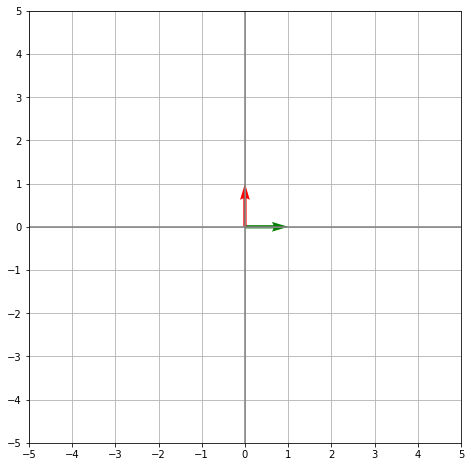

In [4]:
e0 = np.array([1.,0.])
e1 = np.array([0.,1.])

fig,ax = LADS2DSquare(xlow=-5.,xhigh=5.)
ax.LADS2DDrawVector(e0)
ax.LADS2DDrawVector(e1,'r')


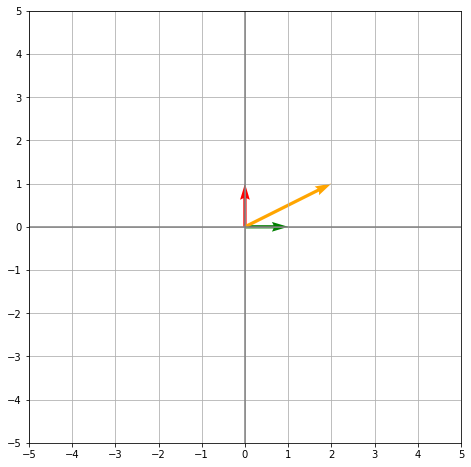

In [5]:
# a is a lienar combination of e1 and e2.

a = 2*e0 + e1

fig,ax = LADS2DSquare(xlow=-5.,xhigh=5.)
ax.LADS2DDrawVector(e0)
ax.LADS2DDrawVector(e1,'r')
ax.LADS2DDrawVector(a,'orange')

#### **Do it:** Try a few more linear combinations of $e_0$ and $e_1$.

You don't have to show your linear combinations. But you should answer these questions.

1. How does the linear combination look if the cofficient of $e_0$ is negative?
2. How does the linear combination look if the coefficient of $e_0$ is zero?
3. How does the linear combination look if the coefficient of $e_0$ is between zero and $1$?
4. How does the linear combination look if the coefficient of $e_0$ is greater than $1$?
5. How does the linear combination look if the coefficients of $e_0$ and $e_1$ are both negative?

After the code cell below there is a text cell where you can answer these questions.

In [ ]:
# Copy, paste, and modify code from above to try the linear combinations.

**Edit this text cell** to answer the questions above. They're copied here.

1. How does the linear combination look if the cofficient of $e_0$ is negative?
2. How does the linear combination look if the coefficient of $e_0$ is zero?
3. How does the linear combination look if the coefficient of $e_0$ is between zero and $1$?
4. How does the linear combination look if the coefficient of $e_0$ is greater than $1$?


#### **Do it:** Do you think that every vector $v$ in $\R^2$ can be written as a linear combination of $e_0$ and $e_1$? Why or why not?

**Edit this text cell** to record your answer. 

Now let's try the same thing with two new vectors $b_0$ and $b_1$.

In [ ]:

b0 = np.array([3, -1])
b1 = np.array([-1, 4])


fig,ax = LADS2DSquare(xlow=-10,xhigh=10)

ax.LADS2DDrawVector(b0)
ax.LADS2DDrawVector(b1,'r')
ax.LADS2DDrawVector(2 * b0 + b1,'purple')

#### **Do it:** Draw some more linear combinations of $b_0$ and $b_1$. 

Do enough examples so you can see the effect of having one or more of the coefficients be negative, zero, betwen zero and $1$, and greater than $1$.


In [ ]:
# Enter your code here. We've given an example to show that you don't have to copy
# and paste from above to draw on the existing figure. 


ax.LADS2DDrawVector(- b0 + b1,'orange')

fig

#### **Do it:** Do you think that you can get every 2D vector as a linear combination of the $b_0$ and $b_1$ in the cell above?

Why or why not?

**Edit this text cell to provide your answer. Don't worry about getting the "correct" answer.**

Let's try to write the vector $[7,1]$ as a linear combination of $b_0=[3,-1]$ and $b_1=[-1,4]$. That is, we have to find scalars $x$ and $y$ so that
$$
         x b_0 + y b_1 = [7,1].
$$
In column notation this is trying to solve the equation 
$$ 
         \begin{bmatrix} 3 \\      -1 \end{bmatrix} x + \begin{bmatrix} -1 \\ 4 \end{bmatrix} y = \begin{bmatrix} 7 \\ 1 \end{bmatrix}
$$

Looking separately at the $0$ entry and the $1$ entry, this is equation is the two equations
$$
\begin{align*}
    3 x - y  & = 7 \\
    - x + 4 y  & = 1.
\end{align*}
$$
So finding a vector as a linear combination of other vectors is the same as solving a system of linear equations. Python and numpy provide a way to solve systems of linear equations:

In [ ]:
# This code makes a "matrix" A whose 0 column is b_0 and whose 1 column is b_1.

A = np.array([b0,b1]).transpose()
print(A)

In [ ]:
# This Python function (part of numpy.linalg, which we imported as "la") solves the equation we're looking at.

la.solve(A,[7,1])

In [ ]:
# Let's check that this worked.

# This command sets x to the zero entry of la.solve(A,[7,1]), and y to the 1 entry.
x,y= la.solve(A,[7,1])
print("x = ",x)
print("y = ",y)

print(x * b0 + y * b1)

**Remark:** The Python code to solve the system of equations wasn't very intuitive. We'll see later why Python has it set up that way. 

## Span

The **span** of $b_0$ and $b_1$ is all the vectors that you can write as a linear combination of $b_0$ and $b_1$. Above, we've shown that $[7,1]$ is "in the **span**" of $b_0$ and $b_1$. This idea is not limited two vectors. The **span** of $n$ vectors $v_0,...,v_{n-1}$, is the collection of all vectors that you can write as linear combinations of $v_0,...,v_{n-1}$.

Now let's try the same thing again, but with these new vectors $a_0$ and $a_1$.

In [ ]:
a0 = np.array([2,-1])
a1 = np.array([-4,2])

fig,ax = LADS2DSquare(xlow=-8.,xhigh=8.)
ax.LADS2DDrawVector(a0)
ax.LADS2DDrawVector(a1,'r')


Once again, let's try to write $[7,1]$ as a linear combination of $a_0$ and $a_1$.

In [ ]:
A = np.empty([2,2])
A[:,0] = a0
A[:,1] = a1
la.solve(A,[7,1])

Did you get a lot of complaints from Python? That's because it couldn't find a solution. Let's look at the vectors $a$, $b$, and $[7,1].$

In [ ]:
v = np.array([7, 1])

# Draw v=[7,1] in blue
ax.LADS2DDrawVector(v,'b')

fig

#### **Do it:** Try to explain in words why you can't write $[7,1]$ (the blue vector) as a linear combination of $a_0$ (the green vector) and $a_1$ (the red vector).

**Edit this text cell** to enter your answer. 

## Linear independence, span, and basis in 2D

Above, we saw that we can write every vector in $\mathbb{R}^2$ as a linear combination of $e_0=[1,0]$ and $e_1=[0,1].$ We saw that we could write every vector in $\mathbb{R}^2$ as a linear combination of $b_0=[3,-1]$ and $b_1=[-1,4]$. 

Said another way, the **span** of $e_0$ and $e_1$ is all of $\mathbb{R}^2$. The **span** of $b_0$ and $b_1$ is all of $\mathbb{R}^2$. When **two** 2D vectors span all of $\mathbb{R}^2$, we say that they are a **basis** or **coordinate system** for $\mathbb{R}^2$.

Not every pair of two 2D vectors is a basis. For example, $a_0$ and $a_1$ above are not a basis for $\mathbb{R}^2$. The two vectors have to "point in different directions"; more precisely, they must not be on the same line. When two 2D vectors lie on the same line, they are **linearly dependent**. When they lie on different lines, they are **linearly independent.**

Two linearly indepdendent 2D vectors will always span $\mathbb{R}^2$ and form a basis of $\mathbb{R}^2$. 

## Bases and coordinates

The reason bases are important is that they give us a way of measuring other vectors. If $z$ is any vector in $\mathbb{R}^2$, then there is a unique solution $(x_0, x_1)$ to the equation $$z = x_0 b_0 + x_1 b_1$$. We call $(x_0,x_1)$ as the **coordinates of $z$ in the basis $b_0, b_1$.**

The basis $e_0=[1,0]$ and $e_1=[0,1]$ is special because we don't need to "solve equations" to find the coordinates of a vector in this basis. The vector $[8,5]$ is just $8 e_0 + 5 e_1$. The coordinates of $[8,5]$ in this basis are $8$ and $5$! For this reason $e_0, e_1$ is called the "standard basis".

It's natural to ask: since the "standard basis" is so easy to use, why don't we just use it all the time?

It turns out that, in many applications, there isn't an obvious coordinate system. In many situations, using a different basis helps to understand what is going on. For example.

- We'll be focused on a subspace of $\mathbb{R}^N$, and we'll need coordinates (a basis) on the subspace. The standard basis vectors might not even be in the subspace.
- We'll study the action of matrices on vector spaces. We'll see that choosing a special basis often helps to understand the matrix better


Every basis for $\mathbb{R}^2$ has two linearly independent vectors. Why two? Here are pictures to help with the discussion.

In [ ]:
a0 = np.array([1,0])
a1 = np.array([0,1])
a2 = np.array([-1,1])

fig,ax = LADS2DSquare(ncols=2,xlow=-3,xhigh=3)

ax[0].LADS2DDrawVector(a0)
ax[0].set_title("Can one vector be a basis?")

ax[1].LADS2DDrawVector(a0)
ax[1].LADS2DDrawVector(a1,'r')
ax[1].LADS2DDrawVector(a2,'b')
ax[1].set_title("Can three vectors be a basis?")


#### **Do it:** Discuss why the one vector $a_0$ isn't a basis for $\mathbb{R}^2$. Discuss why the three vectors $a_0$, $a_1$, $a_2$ aren't a basis for $\mathbb{R}^2$. 

I'll ask you to write your thoughts on this question after giving a few more items to support your thinking and discussion. In the cell below I've added the vector $v=[2,2]$ in purple. What should the coordinates of $v$ be in the proposed (but defective) bases?



In [ ]:
v = np.array([2,2])
ax[0].LADS2DDrawVector(v,'purple')
ax[1].LADS2DDrawVector(v,'purple')

fig

In talking about why $a_0, a_1, a_2$ aren't a basis, I find these observations helpful.

In [ ]:
# Run this cell to check that all these equalities hold

print(a1 == a0+a2)
print(v == 2 * a0 + 2 * a1 + 0 * a2)
print (v == 3 * a0 + 1* a1 + 1 * a2)
print (v == 4 * a0 + 0 * a1 + 2 * a2)

**Edit this cell** and put in your thoughts on why $a_0$ is not a basis for $\mathbb{R}^2$ and why $a_0, a_1, a_2$ is not a basis for $\mathbb{R}^2$. 

## Linear dependence and independence again

Let's look at our three-vector example again. On the right I've drawn $a_2$ with its tail at $a_0$ to illustrate and remind us that $a_1=a_0+a_2$.

In [ ]:
a0 = np.array([1,0])
a1 = np.array([0,1])
a2 = np.array([-1,1])

fig,ax = LADS2DSquare(ncols=2,xlow=-3,xhigh=3)

ax[0].LADS2DDrawVector(a0)
ax[0].LADS2DDrawVector(a1,'r')
ax[0].LADS2DDrawVector(a2,'b')

ax[1].LADS2DDrawVector(a0)
ax[1].LADS2DDrawVector(a1,'r')
ax[1].LADS2DDrawVector(a2,'b',TailAt=a0)



The three vectors $a_0, a_1, a_2$ can't be a basis or coordinate system because they lead to ambiguous coordinates. Adding the first two equations below gives the third one. 

\begin{align*} v & = x a_0 + y a_1 + z a_2 \\
               0 & =   a_0 -   a_1 + a_2 \\
               v & = (x+1) a_0 + (y-1) a_1 + (z+1) a_2
\end{align*}
What are the coordinates of $v$? Are they $(x,y,z)$ or $(x+1, y-1, z+1)$?

Mathematicians use the phrase **linearly dependent** to describe the situation with $a_0, a_1, a_2.$ Here is a more precise definition of linearly dependent and independent that works for any set of vectors (of any size) in any dimension.

> A set of vectors $v_0,...,v_{n-1}$ is **linearly dependent** if one of them can be written as a non-zero linear combination of the rest. The set is vectors is **linearly independent** if the linear combination $x_0 v_0 + ... + x_{n-1} v_{n-1}$ is zero only when the scalars $x_0,...,x_{n-1}$ are all zero.


If two vectors $v$ and $w$ are *not* scalar multiples of each other, then they are **linearly independent.** Above we have seen that $v$ and $w$ are linearly independent, and they are a basis of $\mathbb{R}^2$. We have seen that $a$ and $b$ are linearly dependent, and they are not a basis of $\mathbb{R}^2$. The qualities of linear independence and being a basis go together in this way; this is a very important fact.

> #### Fact: Every basis for $\mathbb{R}^2$ has two vectors, and two 2D vectors are a basis for $\mathbb{R}^2$ if and only if they are linearly independent. 

A generalization of this fact holds in any dimension.

> #### Fact: Every basis for $\mathbb{R}^n$ has $n$ vectors, and $n$ $n$D vectors are a basis for $\mathbb{R}^n$ if and only if they are linearly independent. 

These fact is also important. Don't worry if it sounds a little strange right now. We'll see examples as we go along. 

> #### Fact: If $v_0,...,v_{d-1}$ are linearly independent then they are a basis for the vector space that they span. In a vector space of dimension $d$, every basis has $d$ elements, and every linearly independent set of $d$ vectors is a basis.

## Linear combinations and orthogonal bases in some digitial images

In this example, we'll demonstrate some digital images -- vectors -- that span a three-dimenisonal space in the space of images. We'll see that those vectors, not the standard basis, are a convenient way to study images in this span.

First import three simple grayscale images. We're using commands and methods from PIL, the Python Image Library. 

In [ ]:

# Open three images. The ".convert('L')" part converts the images to grayscale. The "resize" part reduces
# the resolution: otherwise the images are large enough that we might have memory problems.  We still might;
# if so we'll resize again.

sun_gs = Image.open('MATH227_sun.png').convert('L').resize((625,416))
house_gs = Image.open('MATH227_house.png').convert('L').resize((625,416))
tree_gs = Image.open('MATH227_tree.png').convert('L').resize((625,416))

# Let's see what we have so far.

fig,ax=plt.subplots(ncols=3,figsize=[30,10.])
ax[0].imshow(sun_gs,cmap='gray',vmin=0,vmax=255)
ax[1].imshow(house_gs,cmap='gray',vmin=0,vmax=255)
ax[2].imshow(tree_gs,cmap='gray',vmin=0,vmax=255)

We've already seen that a digital image is a vector of pixels. In a color image, each pixel itself has 3 dimensions. In a grayscale image, each pixel is one dimensional. 

The default representation of grayscale images as imported by PIL have three inconvenient properties.

1. The amount of gray is represented as an integer between 0 and 255. I'd prefer to have a real number
2. 0 is black, and 255 is white. For us it is better to work with real numbers, and to have 0 represent the absence of drawing. 

So in the following cell, we're going to convert these images to numpy arrays. Each pixel will be represented by a real number with values between 0 and 1, with 0 representing white and 1 representing black. 

In [ ]:
#
# Dividing by 255. converts each integer between 0 and 255 to a real number ("float" in Python jargon) between 0 and 1. 
# 
# Subtracting from 1 converts 0 to 1 and 1 to 0.

sun = 1. - np.array(sun_gs)/255.
house = 1. - np.array(house_gs)/255.
tree = 1. - np.array(tree_gs)/255.

print("Now we have three numpy arrays of shape ", sun.shape,". So the total number of entries is ",sun.size)

# Let's draw them again and see what we have. I changed the color map to 'binary': it is a grayscale colormap with 
#   0 = white and 1 = black 

fig,ax=plt.subplots(ncols=3,figsize=[14.,10.])
ax[0].imshow(sun,cmap='binary')
ax[1].imshow(house,cmap='binary')
ax[2].imshow(tree,cmap='binary')


Look at the shape and size above: each image is 416 by 625 pixels, so each image is a vector in a 260,000-dimensional vector space! You can combine them just by adding the vectors. For example:

In [ ]:

allthree= sun+ house+ tree 

fig=plt.figure(figsize=[10.,10.])
ax = fig.add_axes([0, 0, 1, 1])

ax.imshow(allthree,cmap='binary')


But we don't have to combine these images with the same intensity!  We can take other linear combinations. Because the entries are between 0 and 1, and because we want to keep it that way, we'll use linear combinations with coefficients between $0$ and $1$. Let's mix these together, with coefficients 0.9, 0.5, and 0.1. 

(If the images overlapped, then to keep the intensity between 0 and 1 in each pixel, we'd have each coefficient between 0 and 1/3, or something like that. Since they don't overlap, as long as each coefficient is between 0 and 1, each pixel will be between 0 and 1.)

In [ ]:

mixed_intensities= 0.9 * sun+ 0.5 * house+  0.1 * tree 

fig=plt.figure(figsize=[10.,10.])
ax = fig.add_axes([0, 0, 1, 1])

ax.imshow(mixed_intensities,cmap='binary')



Here is some code that shows you how to display the two images side-by-side.

In [ ]:
fig,ax=plt.subplots(ncols=2,figsize=[20.,10.])

ax[0].imshow(allthree,cmap='binary')
ax[1].imshow(mixed_intensities,cmap='binary')


Here's the question that this is leading up to. You're given the image on the right, the one that is digitally represented by the vector "mixed_intensities". Can you figure out what the intensities of house, sun, and tree are? 

That is, you know that mixed_intensities is a linear combination of three vectors:
$$
 \text{mixedintensities} = a * \text{sun} + b * \text{house} + c * \text{tree}.
$$
Can you find $a,b,c$?

Notice that:

1. You don't care about the "standard basis", which is 260,000 vectors, each one representing a tiny black dot.
2. You care about a vector in the span of sun, house, and tree.

This is a low-dimensional question in a very high dimensional space. 

It turns out that you've already learned a method for doing this: the projection method that uses the dot product. Remember that the projection of $w$ along $b$ is given by 
$$
   P_b(w) = \frac{b \cdot w}{b \cdot b} b.
$$
Let's see how this helps us.

In [ ]:
# Python needs one-dimensional arrays to compute the dot product using @. Here we again use the rehape method, this time to change our 
# two-dimensional arrays into one-dimensional arrays.

sun_vec = sun.reshape(-1)
house_vec = house.reshape(-1)
tree_vec = tree.reshape(-1)
mixed_intensities_vec = mixed_intensities.reshape(-1)

# We'll use the projection formula with v = tree_vec and w = mixed_intensities_vec

tree_i = (tree_vec @ mixed_intensities_vec) / (tree_vec @ tree_vec)

print(f"Our guess for the coefficient of tree in the mixed_intensities image is {tree_i:0.3f}")

You should get $0.1$ as the guess for the intensity of tree in the mixed-intensity image. This is great! If you look above, $0.1$ is the coefficient of tree we used. Let's use the same method and try to get all three coefficients.

In [ ]:
#
sun_i = (sun_vec @ mixed_intensities_vec) / (sun_vec @ sun_vec)
tree_i = (tree_vec @ mixed_intensities_vec) / (tree_vec @ tree_vec)
house_i = (house_vec @ mixed_intensities_vec) / (house_vec @ house_vec)

print(f"Our guess for the intensities is sun, {sun_i:0.3f}, house, {house_i:0.3f}, tree, {tree_i:0.3f}.")

# Let's also compare the images

recovered_image = sun_i * sun + tree_i * tree + house_i * house

fig,ax=plt.subplots(ncols=2,figsize=[20.,10.])

ax[0].imshow(mixed_intensities,cmap='binary')
ax[1].imshow(recovered_image,cmap='binary')


Try this again with random intensities!

In [ ]:
# this creates an array "intens" of three random numbers between 0 and 1.
intens = rng.random(3)

mystery_image = intens[0] * sun + intens[1] * tree + intens[2] * house

fig=plt.figure(figsize=[10.,10.])
ax = fig.add_axes([0, 0, 1, 1])

ax.imshow(mystery_image,cmap='binary')


#### **Do it:** Borrow from the code above...
...to find the coefficients of sun, house, and tree in mystery_image. Check your answer visually and by comparing the coefficients you get with the entries of the vector "intens".

In [ ]:
# Don't forget that first you have to reshape mystery_image. 

mystery_vec = mystery_image.reshape(-1)

# Now keep going...

#### **Do it:** Create another vector of 3 random numbers, and repeat the experiment.

Create an image by making a linear combination of sun, house, and three. Then check that you can recover that linear combination and image by computing the projection of your image on sun, house, and tree, and adding them up. 

In [ ]:
print(sun_vec@tree_vec)
print(sun_vec@house_vec)
print(house_vec@tree_vec)

### You need three vectors to span a three-dimensional space

This simple example shows why you need three vectors to span a three-dimensional space. Here are two nice vectors.

In [ ]:
fig,ax=plt.subplots(ncols=2,figsize=[14.,10.])
ax[0].imshow(sun,cmap='binary')
ax[1].imshow(house,cmap='binary')


Here is a nice picture.

In [ ]:
fig=plt.figure(figsize=[10.,10.])
ax = fig.add_axes([0, 0, 1, 1])

nicepicture = 0.4 * sun + 0.7 * house + tree
ax.imshow(0.4* sun + 0.7 * house + tree,cmap='binary')

#### **Do it:** 
In the text cell below, write what you think about these questions. Can you write this nice picture as a linear combination of the two vectors "sun" and "house"? Why or why not? How does this show that "sun" and "house" are not a basis for the span of "sun", "house", and "tree"?


**Edit this text cell** to answer the question.

We *can* find the closest image to "nicepicture" that is in the span of "sun" and "house".

In [ ]:
nicepicture_vec = nicepicture.reshape(-1)

sun_i = (sun_vec @ nicepicture_vec) / (sun_vec @ sun_vec)
house_i = (house_vec @ nicepicture_vec) / (house_vec @ house_vec)

projection  = sun_i * sun + house_i*house

fig,ax=plt.subplots(ncols=2,figsize=[14.,10.])
ax[0].imshow(nicepicture,cmap='binary')
ax[1].imshow(projection,cmap='binary')

I named the image on the right "projection" because it is the *projection of nicepicture onto the span of "house" and "sun."* Notice how the formula is a simple generalization of the formula for projection onto the line generated by a single vector. We'll do a lot more of this in the future, when we study **orthonormal bases.**